<a href="https://colab.research.google.com/github/MariaHusak/dyplom_model/blob/main/dyplom_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Mar 11 10:39:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics supervision
!pip install -q sam2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 10.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.2 MB/s eta 0:00:00


## Підключення до Google Drive

In [ ]:
import torch
from google.colab import drive
import os
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/yolo_sam2_project'
os.makedirs(PROJECT_DIR, exist_ok=True)

Mounted at /content/drive


## Підготовка датасету

In [ ]:
from ultralytics.utils.downloads import download

download('https://ultralytics.com/assets/coco128.zip', dir='/content')
!unzip -q /content/coco128.zip -d /content/ 2>/dev/null || true
DATASET_YAML = '/content/coco128/coco128.yaml'

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/coco128.zip to /content/coco128...: 100% ━━━━━━━━━━━━ 263/263 4.1Kfiles/s 0.1s


In [ ]:

DATASET_YAML = 'coco128.yaml'

✅ Готово — ultralytics завантажить датасет автоматично при тренуванні


## Тренування YOLOv8

In [ ]:
from ultralytics import YOLO

MODEL_SIZE = 'yolov8s.pt'

TRAIN_CONFIG = {
    'data':     DATASET_YAML,
    'epochs':   100,
    'imgsz':    640,
    'batch':    16,
    'device':   0,
    'patience': 20,
    'save':     True,
    'project':  f'{PROJECT_DIR}/runs',
    'name':     'yolov8_train',
    'exist_ok': True,
    'hsv_h':    0.015,
    'hsv_s':    0.7,
    'hsv_v':    0.4,
    'fliplr':   0.5,
    'mosaic':   1.0,
    'mixup':    0.1,
}

#Тренування
model = YOLO(MODEL_SIZE)
results = model.train(**TRAIN_CONFIG)

#Результати
metrics = model.val()
print(f"\nmAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

BEST_WEIGHTS = f'{PROJECT_DIR}/runs/yolov8_train/weights/best.pt'
print(f"\nНайкращі ваги збережено: {BEST_WEIGHTS}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=Tr

## Графік навчання

results.png


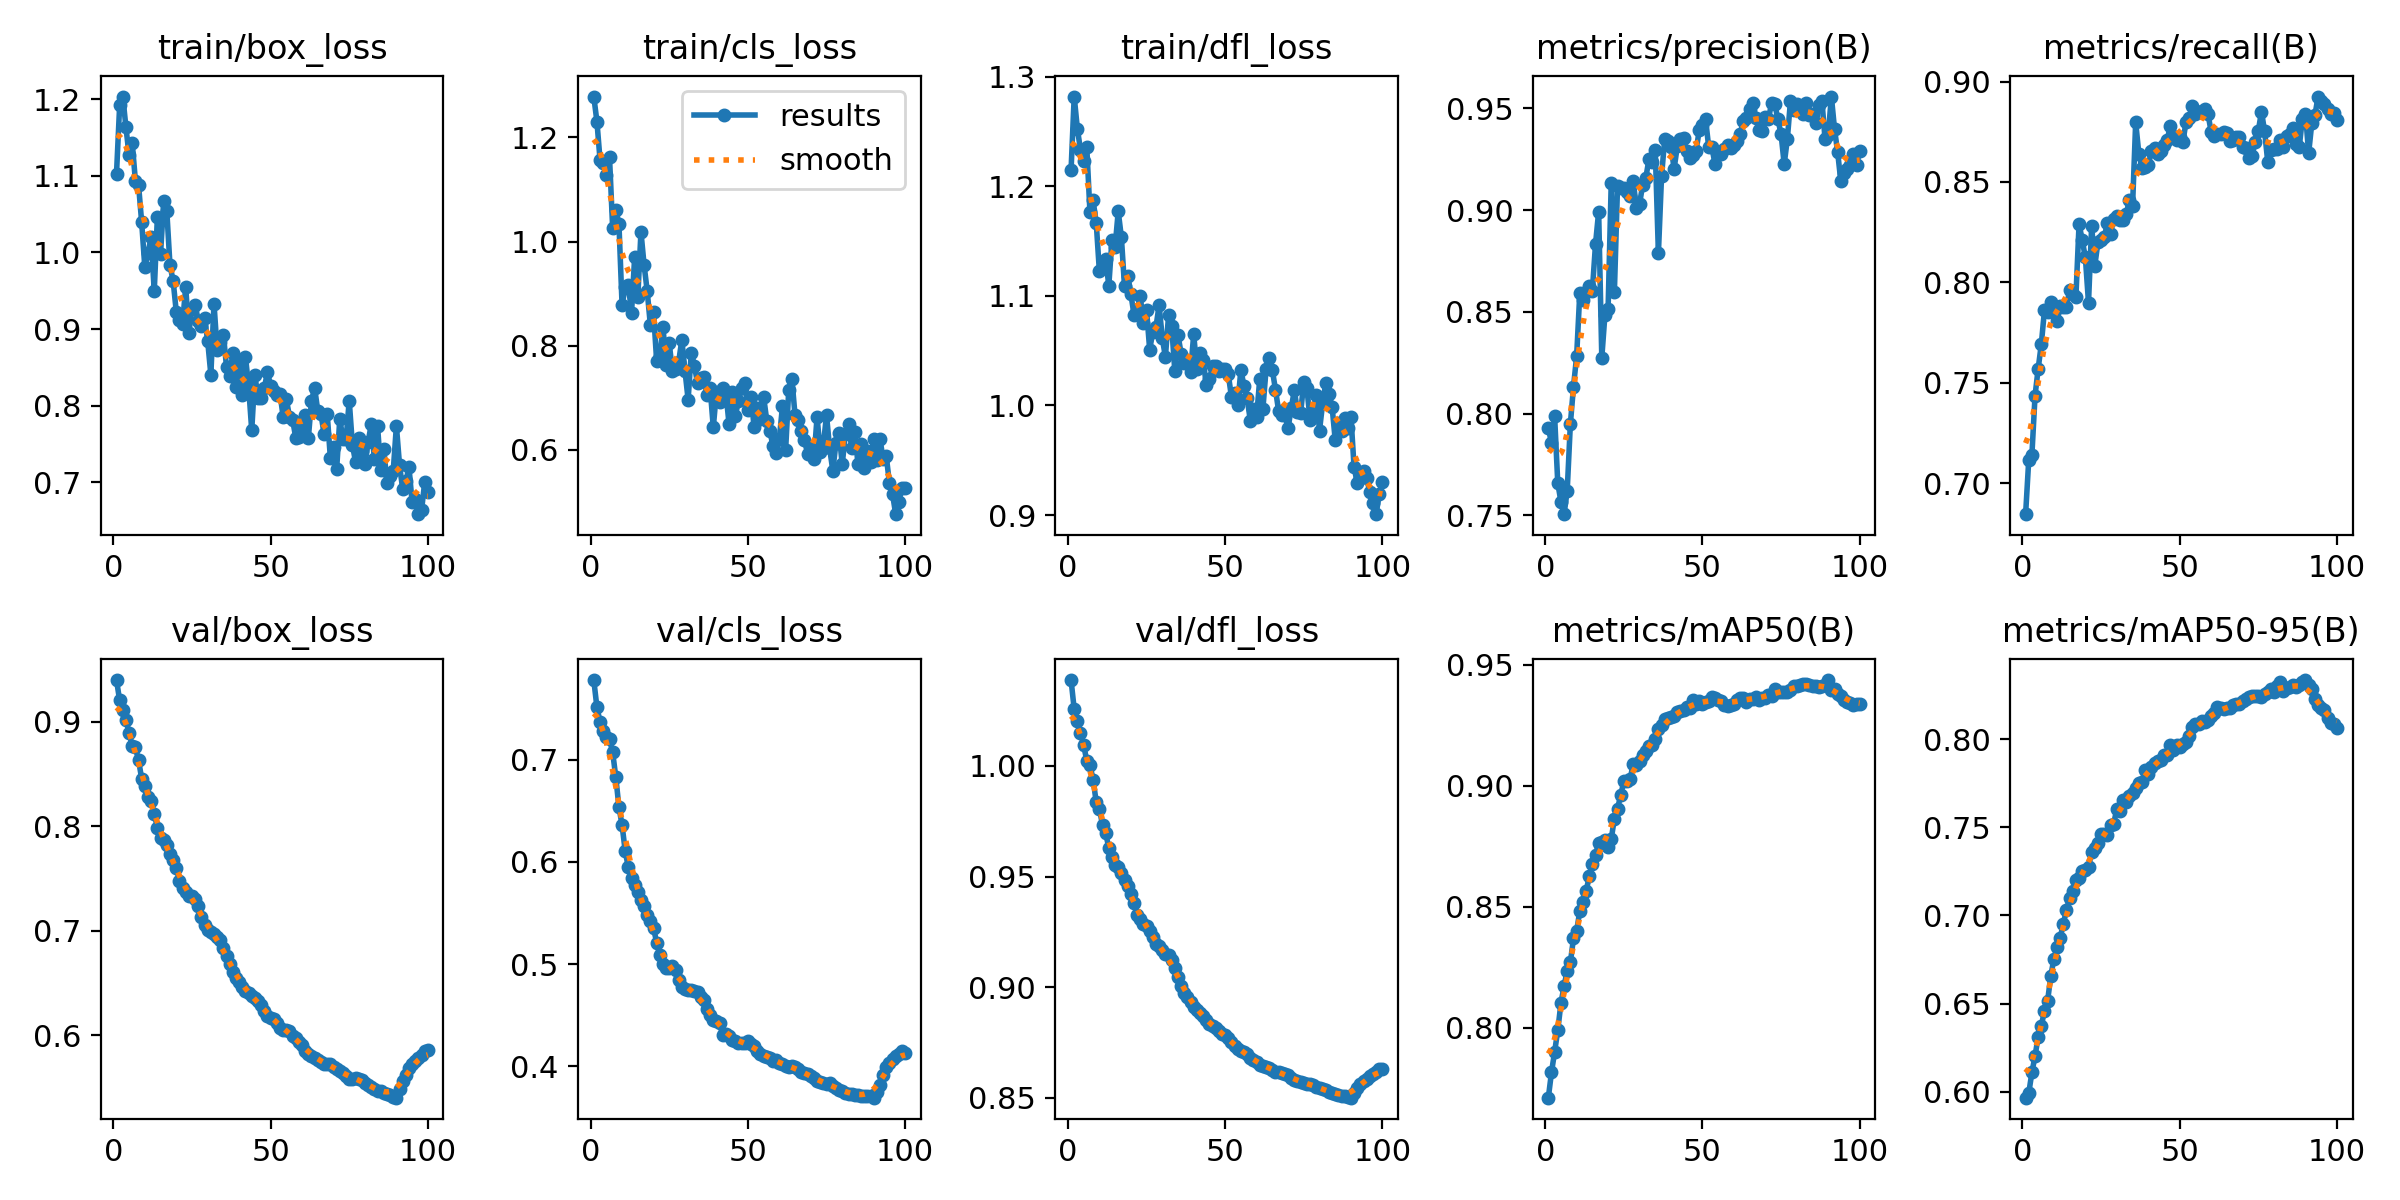

confusion_matrix.png


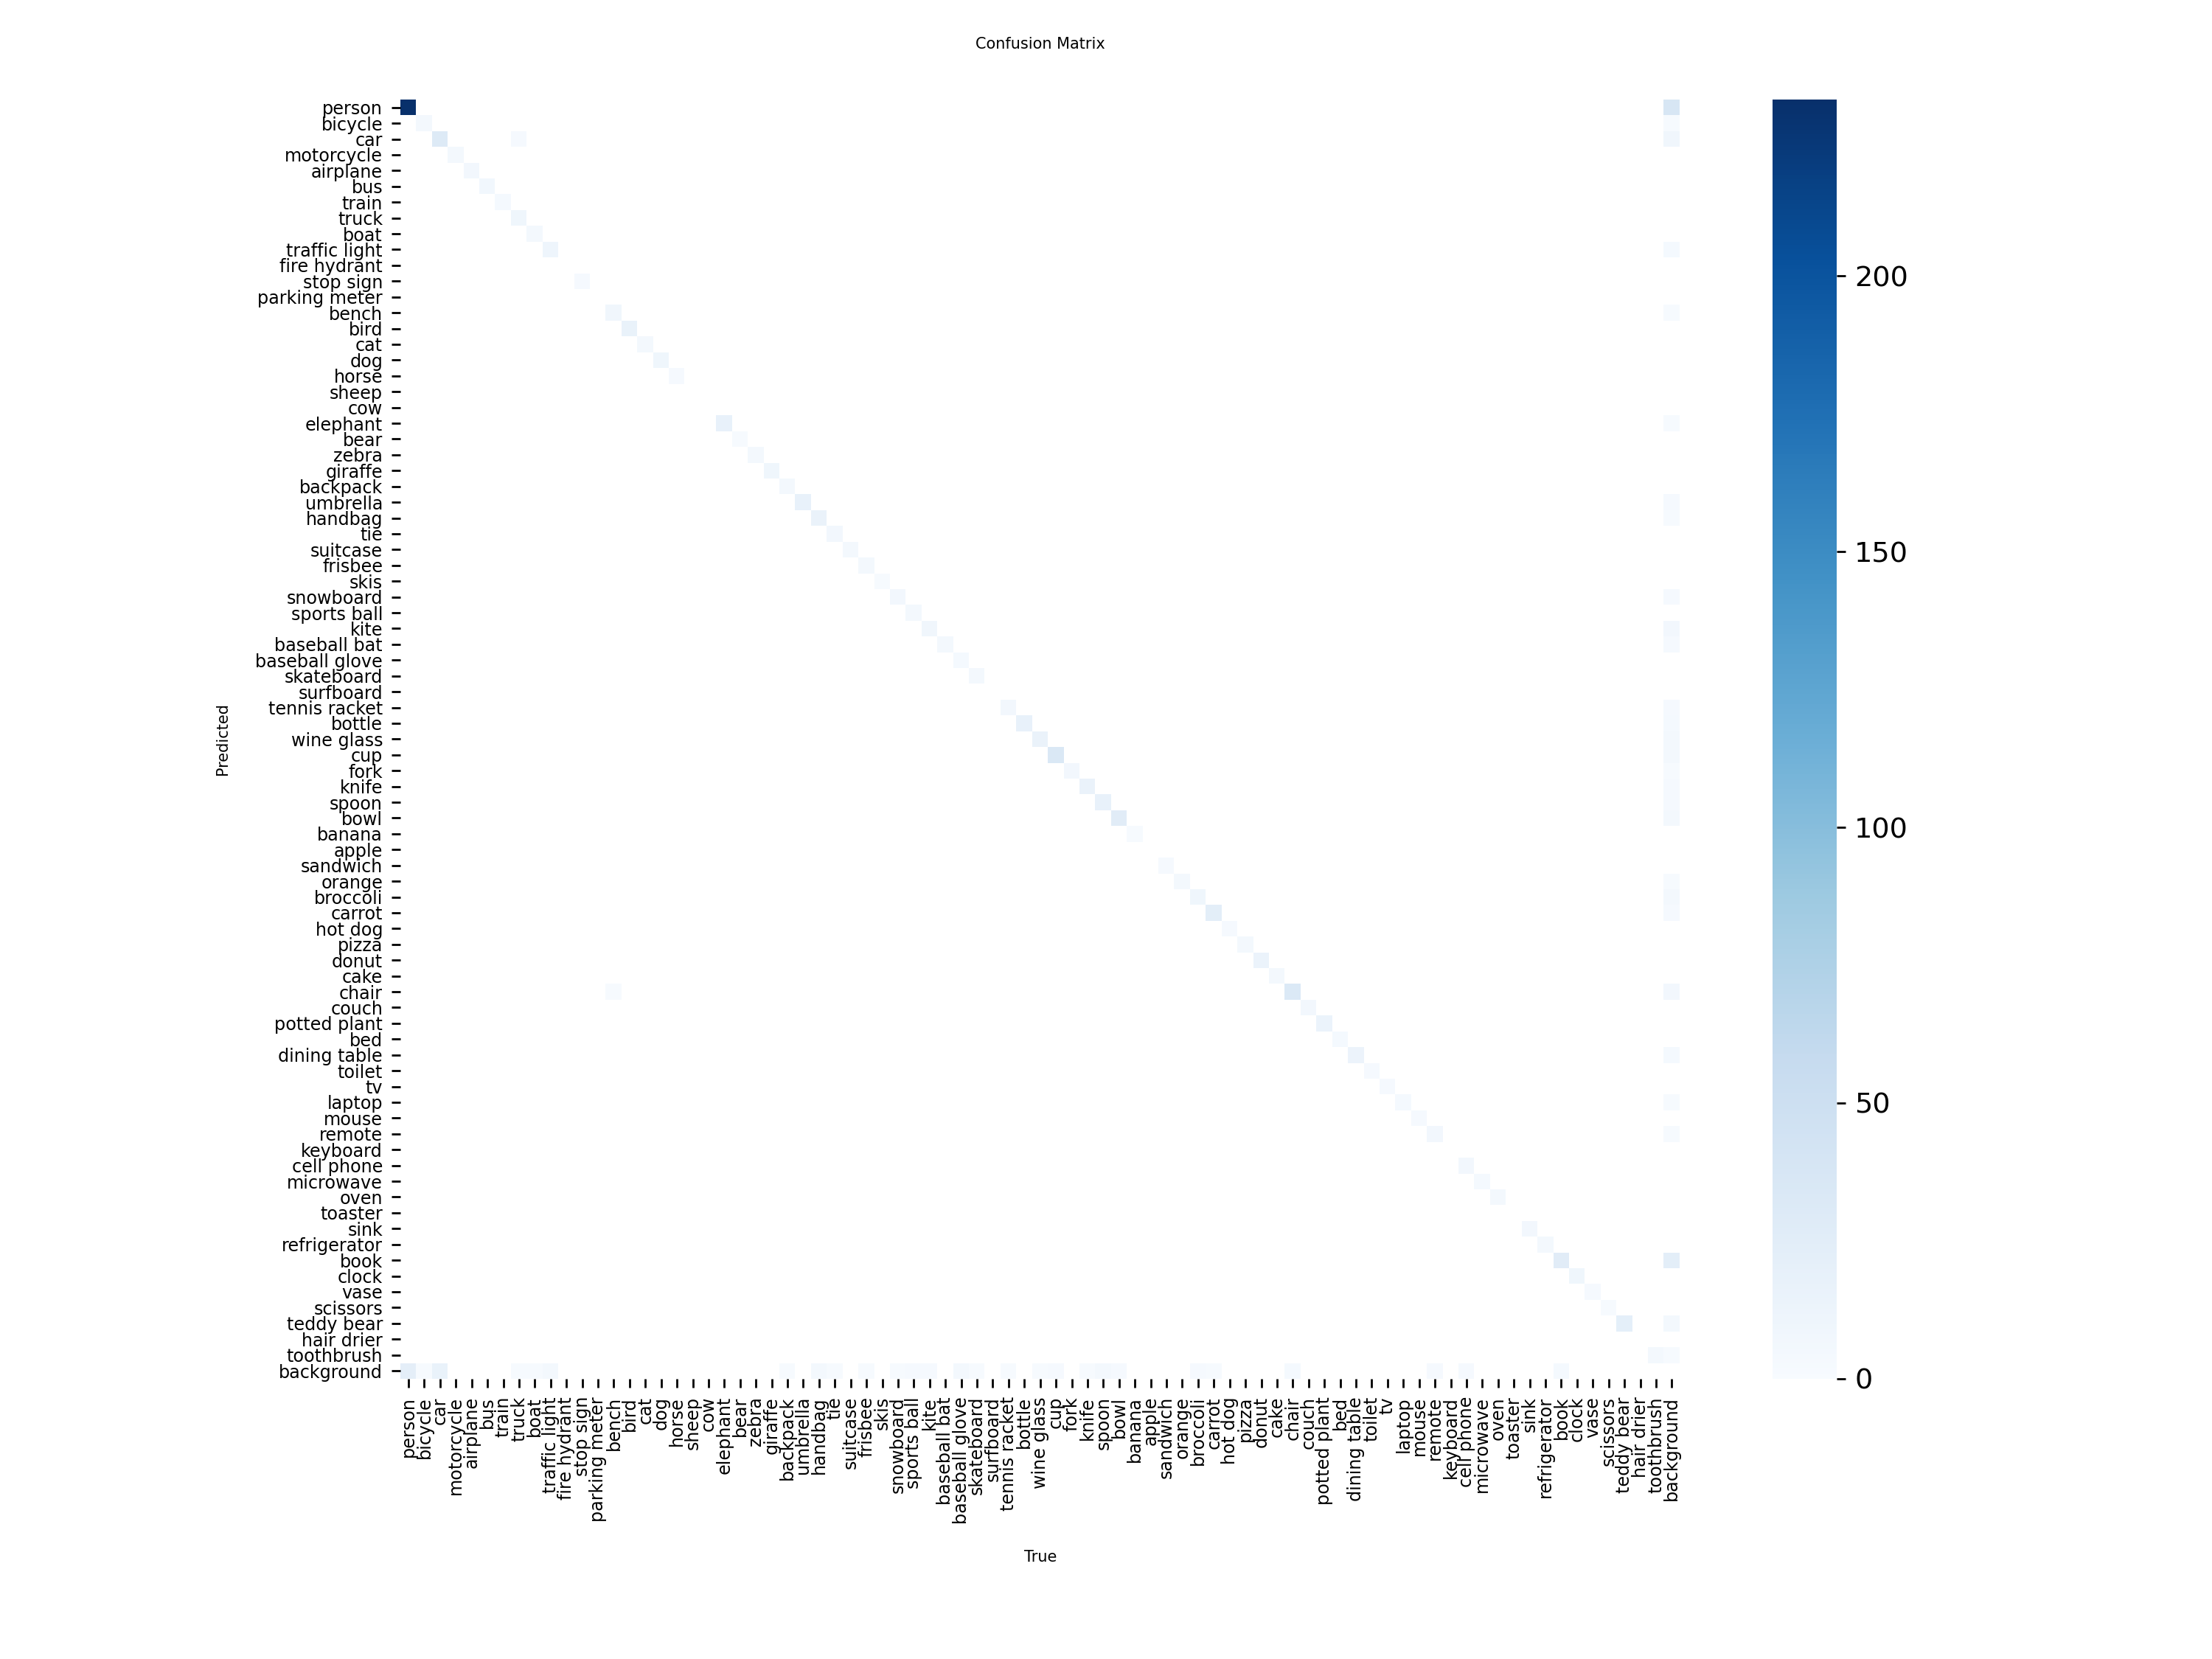

val_batch0_pred.jpg


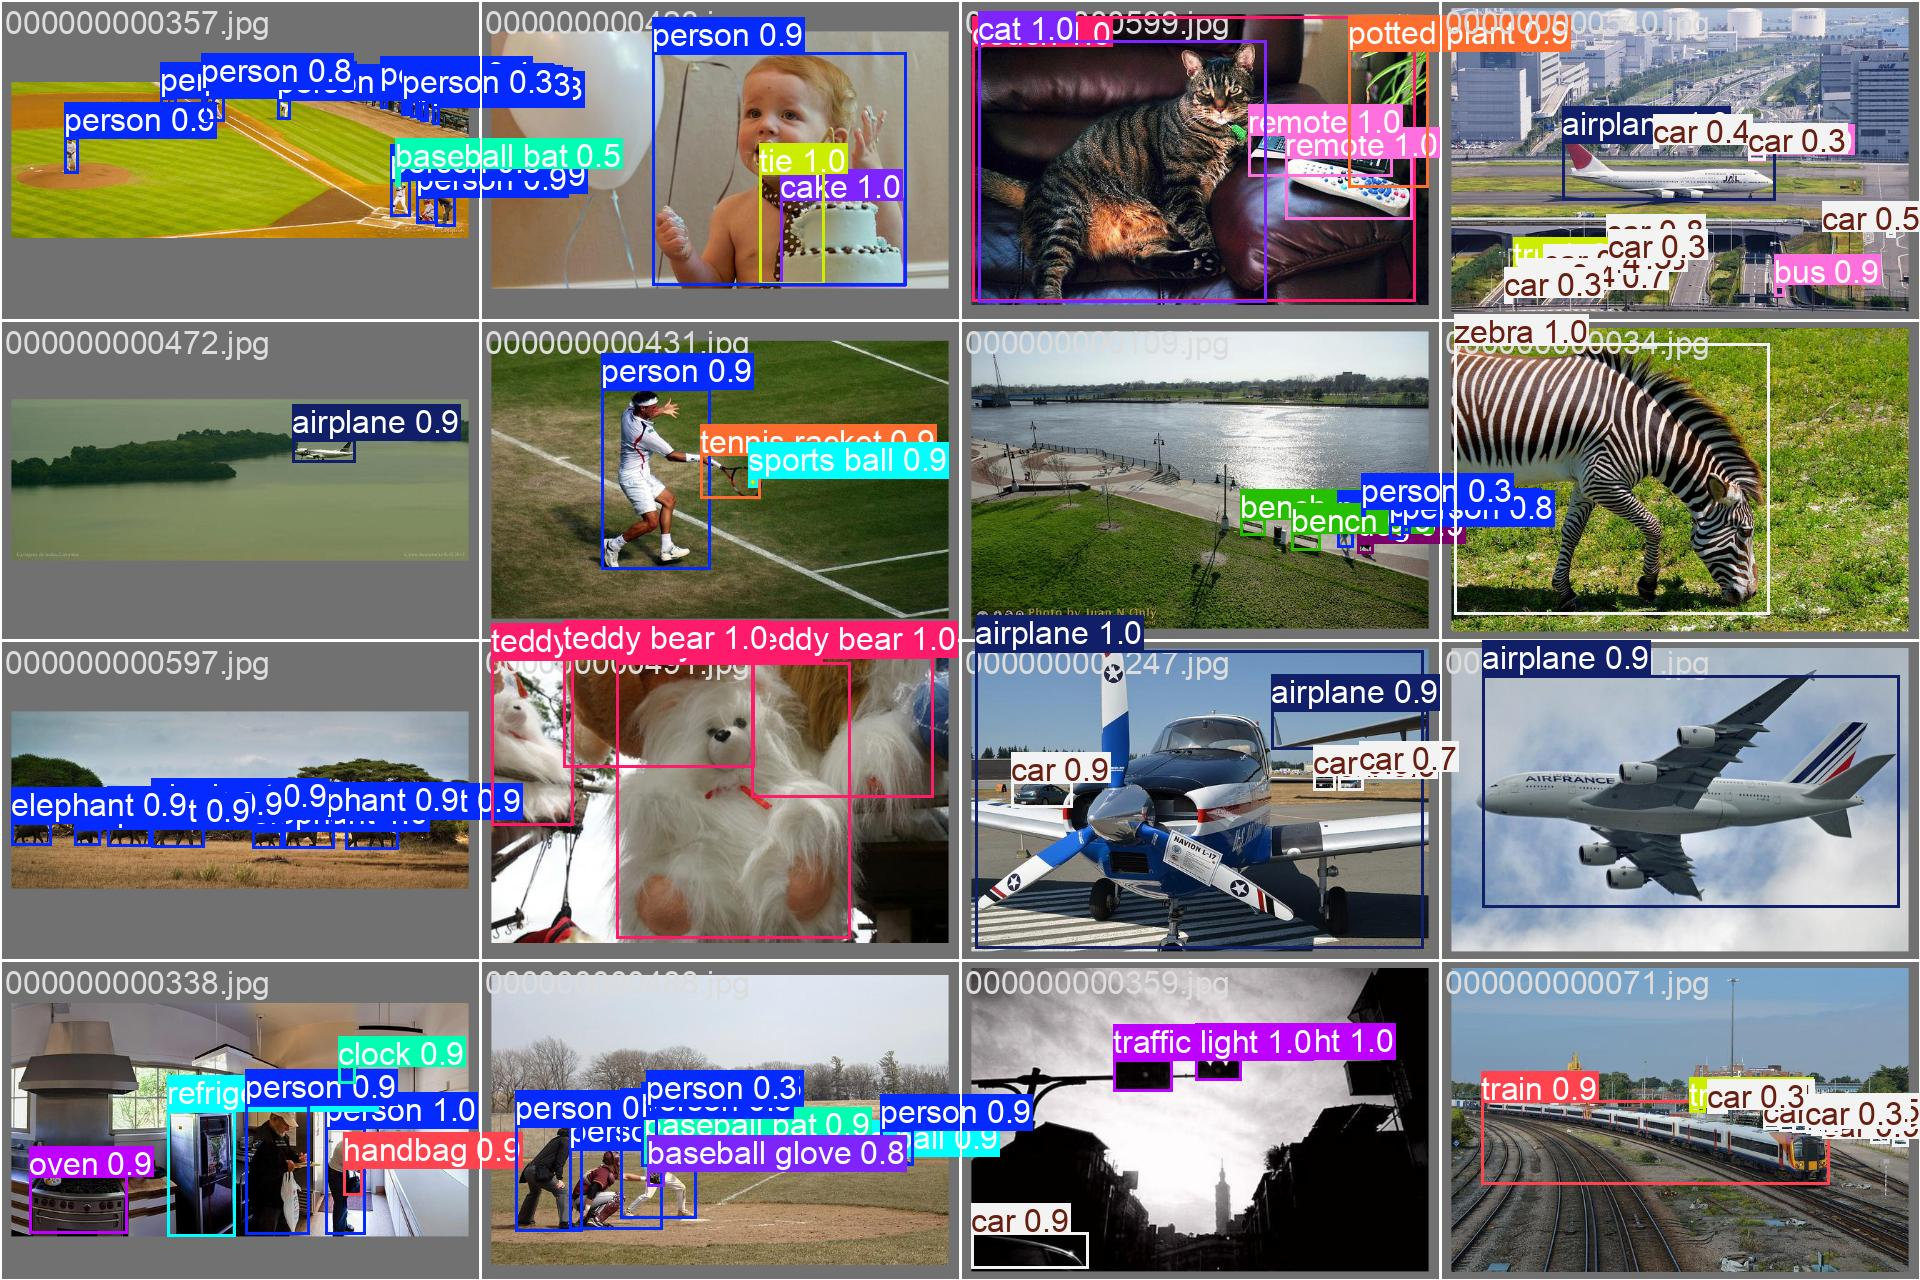

In [ ]:
from IPython.display import Image, display
import glob

results_dir = f'{PROJECT_DIR}/runs/yolov8_train'

for plot_file in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    path = f'{results_dir}/{plot_file}'
    if os.path.exists(path):
        print(plot_file)
        display(Image(path, width=800))

## Завантаження SAM2

In [ ]:
SAM2_DIR = '/content/sam2_checkpoints'
os.makedirs(SAM2_DIR, exist_ok=True)

SAM2_CHECKPOINT = f'{SAM2_DIR}/sam2.1_hiera_small.pt'
SAM2_CONFIG = 'configs/sam2.1/sam2.1_hiera_s.yaml'

if not os.path.exists(SAM2_CHECKPOINT):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt \
        -O {SAM2_CHECKPOINT}
    print('SAM 2 завантажено')
else:
    print('SAM 2 checkpoint вже є')

SAM2_DRIVE = f'{PROJECT_DIR}/sam2.1_hiera_small.pt'
if not os.path.exists(SAM2_DRIVE):
    !cp {SAM2_CHECKPOINT} {SAM2_DRIVE}
    print(f'SAM 2 збережено на Drive: {SAM2_DRIVE}')

SAM 2 завантажено
SAM 2 збережено на Drive: /content/drive/MyDrive/yolo_sam2_project/sam2.1_hiera_small.pt


In [ ]:
import torch
import numpy as np
import cv2
import shutil
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

## Об'єднання YOLOv8 і SAM 2

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Використовуємо: {DEVICE}')

yolo = YOLO(BEST_WEIGHTS)

sam2_model = build_sam2(SAM2_CONFIG, SAM2_CHECKPOINT, device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)

print('YOLOv8 завантажено')
print('SAM 2 завантажено')

PALETTE = [
    (255, 56,  56),   # червоний
    (56,  255, 56),   # зелений
    (56,  56,  255),  # синій
    (255, 255, 56),   # жовтий
    (255, 56,  255),  # фіолетовий
    (56,  255, 255),  # блакитний
]

def run_pipeline(image_path: str, conf: float = 0.5, iou: float = 0.45):
    """
    Запускає повний pipeline: детекція YOLOv8 і сегментація SAM 2.
    Повертає результат як зображення та списки масок і bbox.
    """
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f'Зображення не знайдено: {image_path}')
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # YOLOv8 детекція
    yolo_out = yolo(image_rgb, conf=conf, iou=iou, verbose=False)[0]
    boxes      = yolo_out.boxes.xyxy.cpu().numpy()
    class_ids  = yolo_out.boxes.cls.cpu().numpy().astype(int)
    confidences = yolo_out.boxes.conf.cpu().numpy()
    class_names = yolo.names

    print(f'YOLOv8 знайшов {len(boxes)} об\'єктів')

    if len(boxes) == 0:
        print('Нічого не знайдено. Спробуйте знизити conf.')
        return image_rgb, [], []

    # SAM 2 сегментація
    sam2_predictor.set_image(image_rgb)

    all_masks = []
    for box in boxes:
        masks, scores, _ = sam2_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=box[None, :],
            multimask_output=False,
        )
        all_masks.append(masks[0])

    # Візуалізація
    canvas = image_rgb.copy().astype(np.float32)

    for i, (box, mask, cls_id, conf_val) in enumerate(
        zip(boxes, all_masks, class_ids, confidences)
    ):
        color = np.array(PALETTE[cls_id % len(PALETTE)], dtype=np.float32)
        mask_bool = mask.astype(bool)

        # Напівпрозора маска
        overlay = canvas.copy()
        overlay[mask_bool] = color
        canvas = cv2.addWeighted(canvas, 0.65, overlay, 0.35, 0)

        # Контур маски
        contours, _ = cv2.findContours(
            mask_bool.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(canvas, contours, -1, color.tolist(), 2)

        # Bbox
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color.tolist(), 2)

        # Підпис
        label = f'{class_names[cls_id]} {conf_val:.2f}'

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(canvas, (x1, y1 - th - 8), (x1 + tw + 4, y1), color.tolist(), -1)
        cv2.putText(canvas, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return canvas.astype(np.uint8), all_masks, boxes


def show_result(original_path: str, result_image: np.ndarray):
    original = cv2.cvtColor(cv2.imread(original_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(original);   axes[0].set_title('Оригінал',  fontsize=14); axes[0].axis('off')
    axes[1].imshow(result_image); axes[1].set_title('YOLOv8 + SAM 2', fontsize=14); axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/last_result.jpg', dpi=150, bbox_inches='tight')
    plt.show()

print('Всьо працює')

Використовуємо: cuda
YOLOv8 завантажено
SAM 2 завантажено
Всьо працює


## Тест на зображенні

Saving 20230215_162248.jpg to 20230215_162248.jpg
🖼️  Тест на: 20230215_162248.jpg
🔍 YOLOv8 знайшов 1 об'єктів


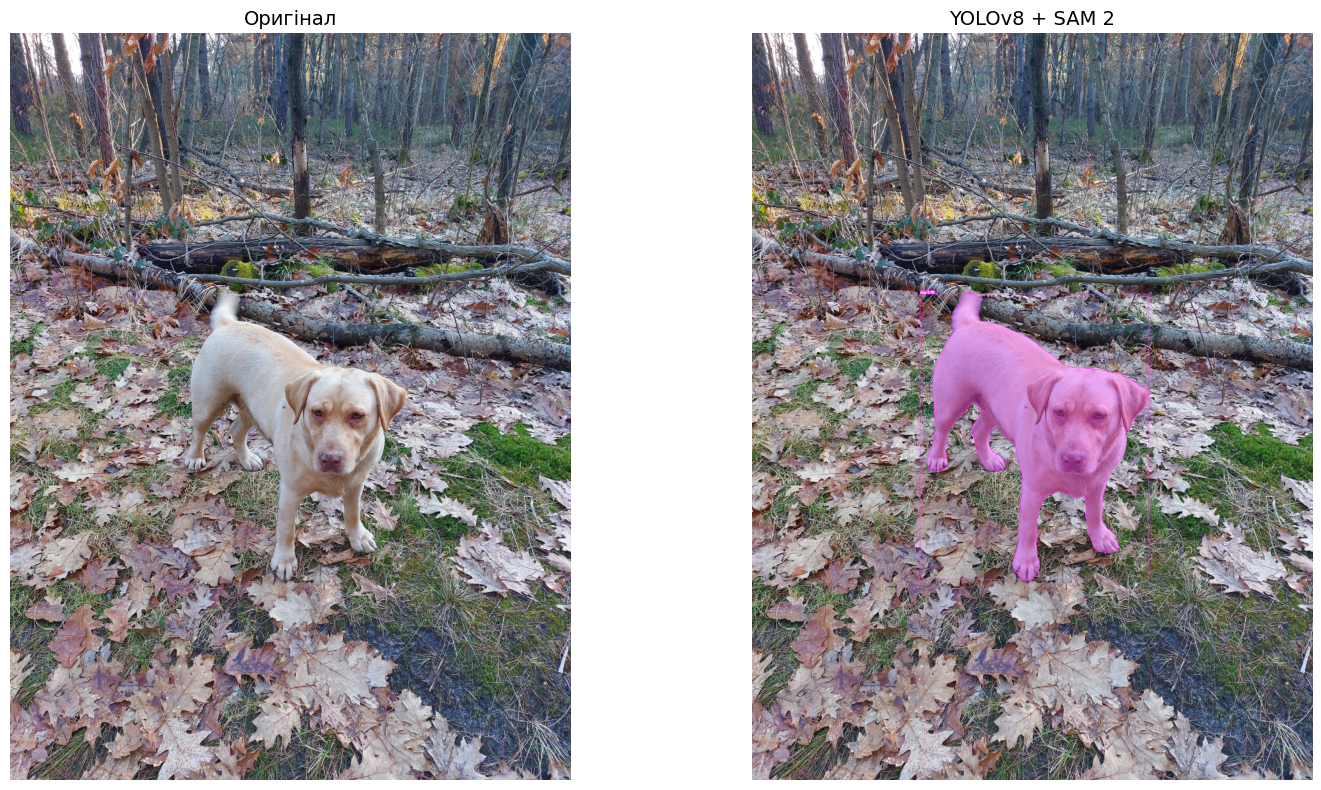


Знайдено об'єктів: 1
Результат збережено: /content/drive/MyDrive/yolo_sam2_project/last_result.jpg
Збережено: /content/drive/MyDrive/yolo_sam2_project/result_fullsize.jpg
Розмір зображення: 3468x4624px


In [ ]:
from google.colab import files
uploaded = files.upload()
TEST_IMAGE = list(uploaded.keys())[0]

if TEST_IMAGE:
    print(f'Тест на: {TEST_IMAGE}')
    result_img, masks, boxes = run_pipeline(TEST_IMAGE, conf=0.4)
    show_result(TEST_IMAGE, result_img)
    print(f'\nЗнайдено об\'єктів: {len(boxes)}')
    print(f'Результат збережено: {PROJECT_DIR}/last_result.jpg')
else:
    print('Вкажіть шлях до зображення у TEST_IMAGE')

output_path = f'{PROJECT_DIR}/result_fullsize.jpg'
result_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
cv2.imwrite(output_path, result_bgr)
print(f"Збережено: {output_path}")
print(f"Розмір зображення: {result_img.shape[1]}x{result_img.shape[0]}px")

## Збереження фінальних ваг

In [ ]:
yolo_best = f'{PROJECT_DIR}/runs/yolov8_train/weights/best.pt'
sam2_weights = f'{PROJECT_DIR}/sam2.1_hiera_small.pt'

zip_path = f'{PROJECT_DIR}/model_weights.zip'
!zip -j {zip_path} {yolo_best} {sam2_weights}
print(f'Архів збережено: {zip_path}')

print(f'best.pt: {os.path.getsize(yolo_best)/1024/1024:.1f} MB')
print(f'sam2.1_hiera_small: {os.path.getsize(sam2_weights)/1024/1024:.1f} MB')
print(f'Архів разом: {os.path.getsize(zip_path)/1024/1024:.1f} MB')

files.download(zip_path)

  adding: best.pt (deflated 8%)
  adding: sam2.1_hiera_small.pt (deflated 7%)
Архів збережено: /content/drive/MyDrive/yolo_sam2_project/model_weights.zip
best.pt: 21.5 MB
sam2.1_hiera_small: 175.9 MB
Архів разом: 183.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>